In [1]:
%matplotlib inline

import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib import rc, rcParams
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle as pkl

# Make use of TeX\ufeff
rc('text',usetex=True)
# Change all fonts to 'Computer Modern'
rc('font',**{'size':14, 'family':'serif','serif':['Times New Roman']})
rc('xtick.major', size=5, pad=7)
rc('xtick', labelsize=15)
rc('ytick.major', size=5, pad=7)
rc('ytick', labelsize=15)

# uses matplotlib-label-lines, see for example https://github.com/cphyc/matplotlib-label-lines
from labellines import labelLine, labelLines

# this needs to point to the folder where darkelf.py is stored
work_dir = os.getcwd()
sys.path.append(work_dir+"/..")
plotdir=work_dir+"/plots/"

from darkelf import darkelf, targets

In [2]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0,exposure=1):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/(R*exposure) # exposure in kg-year (default 1)

In [3]:
masslist=np.logspace(6,15,100) # [eV]

# Plot v dists - Dark Proton - SENSEI and Xenon Limits (28/4/26)

In [4]:

kcut=1.2e4 # restrict phase space for massive mediator


targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, naive","Si - halo","Si - halo, max charged",r"Si - disk, $\delta \ll 1$","Si - disk, no capture","Si - disk, little both"]

kept_indices = (1,2,4,5)
therm_drops = (3,4)

masslist_pD = masslist


In [5]:

mX=1.0e8 # specify the dark matter mass (to be updated later)

sqrtmrat = 1e0

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":1},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":0.1,"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":0.1,"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 ),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive



target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

# flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

# etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [6]:
# convert cm^2 ref electron cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

In [7]:
# same as above for nuclear
# also from 1509.01598

def mu_chiN_GeV(mchi_eV, mN_GeV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * mN_GeV) / (mchi_GeV + mN_GeV)

def kappa_to_sigmaN_ref(kappa, mchi_eV, Z, mN_GeV, qref_GeV=None):
    """
    Reference DM-nucleus cross section for a massless kinetically mixed mediator.

    sigma_N(qref) = 16 pi alpha^2 kappa^2 Z^2 mu_chiN^2 / qref^4

    By default qref = alpha * m_e, matching the usual electron-reference convention.
    """
    if qref_GeV is None:
        qref_GeV = alpha * m_e_GeV

    muN = mu_chiN_GeV(mchi_eV, mN_GeV)

    sigmaN_GeVminus2 = (
        16 * np.pi * alpha**2
        * np.asarray(kappa, dtype=float)**2
        * Z**2
        * muN**2
        / qref_GeV**4
    )

    return sigmaN_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [8]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_pD_11_5_26"
fname = "lim_massless_SENSEI_exp_pD_17_6_26"

if task == "write":

    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)


lim_kappa_pD_e = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

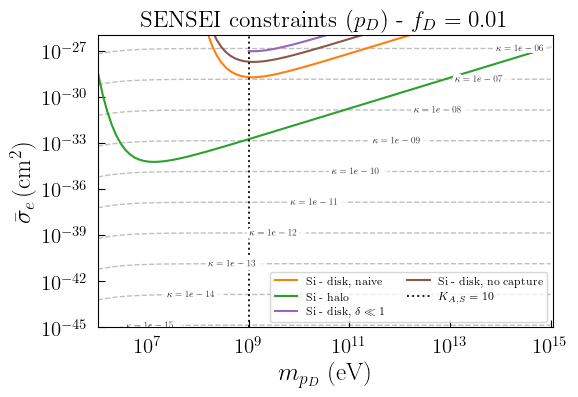

In [9]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0, 1.0, 10))




# for i in range(len(lim_massless)):
#     axs.plot(
#         masslist,
#         lim_massless[i],
#         label=targetlabels[i],
#         color=colors[i]
#     )

therm_val = 1e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)

for i in kept_indices:
    axs.plot(
        masslist[therm_ind:] if (i in therm_drops) else masslist,
        lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
        label=targetlabels[i],
        color=colors[i]
    )

axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6, 1.1e15])
# axs.set_ylim([1e-49, 1.1e-26])
axs.set_ylim([1e-45, 1.1e-26])
axs.set_xlabel("$m_{p_D}$ (eV)", fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$", fontsize=18)
axs.tick_params(direction="in", which="both")

axs.set_title(r"SENSEI constraints ($p_D$) - $f_D = 0.01$")


# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)

# ------------------------------------------------------------------
# Labelled vertical line for legend
# ------------------------------------------------------------------

vline_x = therm_val

therm_line = axs.axvline(
    vline_x,
    color="black",
    lw=1.4,
    ls=":",
    alpha=0.9,
    zorder=2,
    # label=r"$m_{p_D}=1\,\mathrm{GeV}$"
)

# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
# main_handles = handles[:len(lim_massless)]
# main_labels = labels[:len(lim_massless)]
main_handles = handles[:len(kept_indices)]
main_labels = labels[:len(kept_indices)]

main_handles.append(therm_line)
main_labels.append(r"$K_{A,S} =10$")

axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)

### Now Nuclear

In [10]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    # if R == 0.0:
    #     return 1.0
    if (not np.isfinite(R)) or R <= 0.0:
        return np.inf
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [11]:
lim_massless_nuc=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless_nuc.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
            ER_min_eV = 4.9e3,
            ER_max_eV = 40.9e3 # 1805.12562
        )
        for mX in masslist
    ])

lim_massless_nuc_DD = np.array(lim_massless_nuc)

lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless_nuc[i], masslist)
    for i in range(len(lim_massless_nuc))
]

# use isotope 131 as reference
lim_sigmaN = [
    kappa_to_sigmaN_ref(lim_massless_nuc[i], masslist, 54.0, 131.0)
    for i in range(len(lim_massless_nuc))
]

lim_kappa_pD_N = lim_massless_nuc_DD

Si
Si
Si
Si
Si
Si
Si


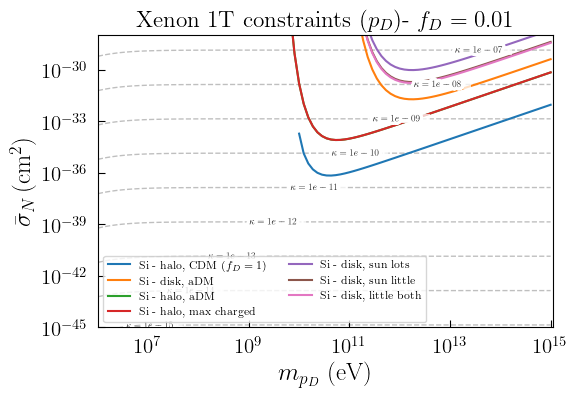

In [13]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
# for i in range(len(lim_sigmae)):
#     axs.plot(masslist,lim_sigmaN[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6,1.1e15])
# axs.set_ylim([1e-49,1.1e-28])
axs.set_ylim([1e-45,1.1e-28])
axs.set_xlabel("$m_{p_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($p_D$)- $f_D = 0.01$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

############################# I THINK THIS IS THE ISSUE, I NEED TO BE USING THE CONVERSION FOR NUCLEI HERE RATHER THAN SIGMAE

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
# floor_file = "Xe_SI.txt"

# m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# # If your x-axis is m_chi in eV:
# m_floor_eV = m_floor_GeV * 1e9

# # --- add to existing axes ---
# axs.plot(
#     m_floor_eV,
#     sigma_floor_cm2,
#     ls="--",
#     lw=2.0,
#     color="0.2",
#     alpha=0.7,
#     label=r"Xe SI $\nu$ floor"
# )


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower left"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

move the damn legend

In [ ]:
smaller = [min(a, b) for a, b in zip(list1, list2)]

### combined plots

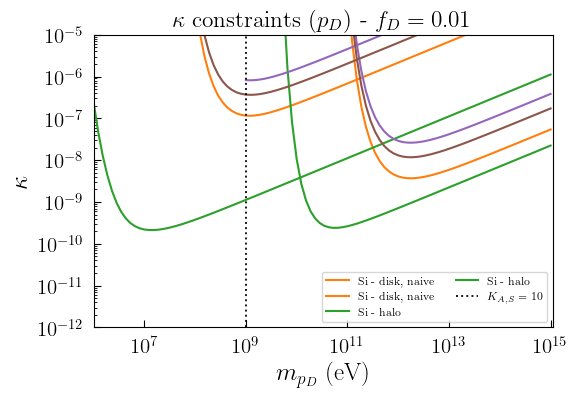

In [66]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0, 1.0, 10))


therm_val = 1e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)

for i in kept_indices:
    axs.plot(
        masslist[therm_ind:] if (i in therm_drops) else masslist,
        lim_kappa_pD_e[i][therm_ind:] if (i in therm_drops) else lim_kappa_pD_e[i],
        label=targetlabels[i],
        color=colors[i]
    )
    axs.plot(
        masslist[therm_ind:] if (i in therm_drops) else masslist,
        lim_kappa_pD_N[i][therm_ind:] if (i in therm_drops) else lim_kappa_pD_N[i],
        label=targetlabels[i],
        color=colors[i]
    )


    

axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6, 1.1e15])
# axs.set_ylim([1e-49, 1.1e-26])
axs.set_ylim([1e-12, 1.0e-5])
axs.set_xlabel("$m_{p_D}$ (eV)", fontsize=18)
axs.set_ylabel(r"$\kappa$", fontsize=18)
axs.tick_params(direction="in", which="both")

axs.set_title(r"$\kappa$ constraints ($p_D$) - $f_D = 0.01$")

# ------------------------------------------------------------------
# Labelled vertical line for legend
# ------------------------------------------------------------------

vline_x = therm_val

therm_line = axs.axvline(
    vline_x,
    color="black",
    lw=1.4,
    ls=":",
    alpha=0.9,
    zorder=2,
    # label=r"$m_{p_D}=1\,\mathrm{GeV}$"
)

# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
# main_handles = handles[:len(lim_massless)]
# main_labels = labels[:len(lim_massless)]
main_handles = handles[:len(kept_indices)]
main_labels = labels[:len(kept_indices)]

main_handles.append(therm_line)
main_labels.append(r"$K_{A,S} =10$")

axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)

### debug plots

In [45]:
mX = 50e9  # eV
kappa_ref = 1e-9
ER_min_eV = 4.9e3
ER_max_eV = 40.9e3

target = target_list[0]
target.update_params(mX=mX, mediator="massless")

print("target:", target.target)
print("vdist:", target.vdist)
print("mX:", target.mX)
print("rhoX:", target.rhoX)
print("eVtokg:", target.eVtokg)
print("c0:", getattr(target, "c0", None))
print("c0cms:", getattr(target, "c0cms", None))

R = target.R_mc(
    material="Xe",
    kappa=kappa_ref,
    q_dm=1.0,
    vdist="halo",
    ER_min_eV=ER_min_eV,
    ER_max_eV=ER_max_eV,
)
print("R_mc:", R)
print("events in 1 ty:", R * 1000.0)
print("kappa limit:", kappa_ref * np.sqrt(3/(R*1000.0)) if R > 0 else np.nan)

target: Si
vdist: halo
mX: 50000000000.0
rhoX: 400000000.0
eVtokg: 1.78e-36
c0: 299792.458
c0cms: 29979245800.0
R_mc: 5.848585775385815
events in 1 ty: 5848.585775385815
kappa limit: 2.2648278434075245e-11


In [ ]:
for ER in [4.9e3, 1e4, 2e4, 4e4]:
    print("ER =", ER)
    print("vmin =", vmin_nr(ER, NR_MATERIALS["Xe"].isotopes[3].mass_eV, target.mX))
    print("eta =", target.etav(target.vmin_nr(ER, NR_MATERIALS["Xe"].isotopes[3].mass_eV, target.mX)))
    print("dRdER =", target.dRdER_mc(ER, material="Xe", kappa=1e-9, q_dm=1.0, vdist="halo"))

ER = 4900.0


AttributeError: 'darkelf' object has no attribute 'vmin_nr'

In [44]:
print(masslist[:10], masslist[-10:])
print(lim_massless_nuc_DD[0][:10], lim_massless_nuc_DD[0][-10:])
print(lim_sigmae[0][:10], lim_sigmae[0][-10:])

[1000000.         1232846.73944207 1519911.08295293 1873817.42286038
 2310129.70008316 2848035.8684358  3511191.73421513 4328761.28108306
 5336699.23120631 6579332.24657568] [1.51991108e+14 1.87381742e+14 2.31012970e+14 2.84803587e+14
 3.51119173e+14 4.32876128e+14 5.33669923e+14 6.57933225e+14
 8.11130831e+14 1.00000000e+15]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] [9.99442486e-10 1.10971028e-09 1.23214530e-09 1.36808999e-09
 1.51903488e-09 1.68663499e-09 1.87272793e-09 2.07935409e-09
 2.30877899e-09 2.56351813e-09]
[6.16514622e-16 7.03515684e-16 7.88363846e-16 8.68993168e-16
 9.43840590e-16 1.01189070e-15 1.07264370e-15 1.12603343e-15
 1.17232294e-15 1.21199910e-15] [1.40600646e-33 1.73336857e-33 2.13695589e-33 2.63451719e-33
 3.24793403e-33 4.00418297e-33 4.93652202e-33 6.08595318e-33
 7.50302563e-33 9.25005879e-33]


### Wimp comparison

In [10]:
from millicharge_nr import attach_wimp_SI_nr_methods
attach_wimp_SI_nr_methods(darkelf)

In [11]:
lim_wimp_SI_nuc = []

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target, vinfo in zip(target_list, vs_list):
    print(target.target, vinfo["vdist"])

    lim_wimp_SI_nuc.append([
        target.sigma_n_limit_wimp_SI(
            material="Xe",
            exposure_kgyr=expXENON1T,
            n_limit=2.3,
            fp_over_fn=1.0,          # standard isospin-conserving SI WIMP
            vdist=vinfo["vdist"],    # use same halo/disk choice as the target
            ER_min_eV=4.9e3,
            ER_max_eV=40.9e3,        # XENON1T 1805.12562 NR ROI
            npts=800,
            sigma_ref_cm2=1e-45,
        )
        for mX in masslist
        for _ in [setattr(target, "mX", mX)]
    ])

lim_wimp_SI_nuc_DD = np.array(lim_wimp_SI_nuc)

Si halo
Si disk
Si disk
Si disk
Si disk
Si disk
Si disk


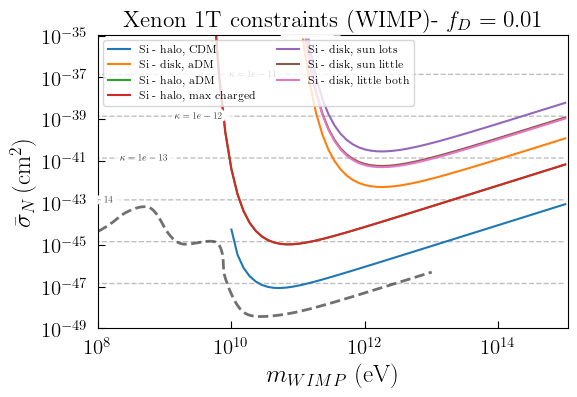

In [13]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_wimp_SI_nuc_DD)):
    axs.plot(masslist,lim_wimp_SI_nuc_DD[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e8,1.1e15])
axs.set_ylim([1e-49,1.1e-35])
axs.set_xlabel("$m_{WIMP}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints (WIMP)- $f_D = 0.01$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_wimp_SI_nuc_DD)]
main_labels = labels[:len(lim_wimp_SI_nuc_DD)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

The CDM line matches xenon wimp limits from eg fig 5 of 1805.12562

# Plot v dists - Dark Electron - SENSEI and Xenon Limits (22/4/26)

In [12]:
# masslist=np.logspace(3,10,100)

sqrtmrat = 1e2

targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

masslist_eD = masslist / sqrtmrat**2

kept_indices = (1,2,4,5)
therm_drops = (3,4)

In [27]:
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

# need to divide fD by mass ratio to account for lower number density (dictated by dark proton mass rather than dark electron mass for fixed \rho_{DM})
fDcase = 0.01 / sqrtmrat**2 

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":1},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":fDcase}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

KeyboardInterrupt: 

In [14]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2



In [15]:
# same as above for nuclear
# also from 1509.01598

def mu_chiN_GeV(mchi_eV, mN_GeV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * mN_GeV) / (mchi_GeV + mN_GeV)

def kappa_to_sigmaN_ref(kappa, mchi_eV, Z, mN_GeV, qref_GeV=None):
    """
    Reference DM-nucleus cross section for a massless kinetically mixed mediator.

    sigma_N(qref) = 16 pi alpha^2 kappa^2 Z^2 mu_chiN^2 / qref^4

    By default qref = alpha * m_e, matching the usual electron-reference convention.
    """
    if qref_GeV is None:
        qref_GeV = alpha * m_e_GeV

    muN = mu_chiN_GeV(mchi_eV, mN_GeV)

    sigmaN_GeVminus2 = (
        16 * np.pi * alpha**2
        * np.asarray(kappa, dtype=float)**2
        * Z**2
        * muN**2
        / qref_GeV**4
    )

    return sigmaN_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [16]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_22_4_22"
# fname = "lim_massless_SENSEI_exp_11_5_26"
# fname = "lim_massless_SENSEI_exp_31_5_26"
# fname = "lim_massless_SENSEI_exp_1_6_26"
fname = "lim_massless_SENSEI_exp_17_6_26"

if task == "write":
    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist_eD])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist_eD])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)

lim_kappa_eD_e = [sigmae_to_kappa_exact(lim_massless[i], masslist_eD) for i in range(len(lim_massless))]



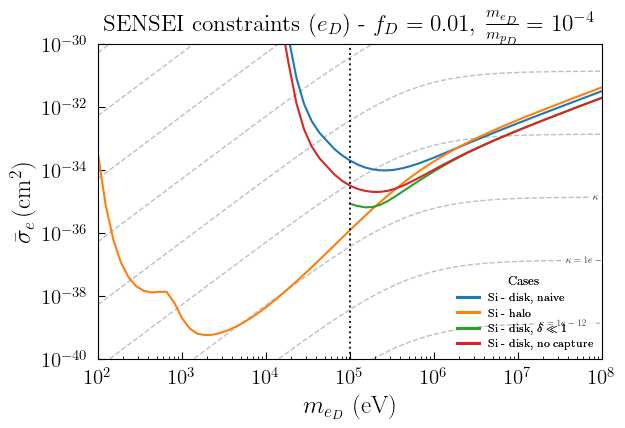

In [52]:
fig, axs = plt.subplots(figsize=(6,4.2))

# cmap = plt.get_cmap('tab10')
# colors = cmap(np.linspace(0.0,1.0,10))
cmap = plt.get_cmap("tab10")
colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
# colors[1], colors[2] = colors[2], colors[1]

# Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices}

# for i in range(len(lim_massless)):
#     axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
# axs.set_xscale("log")   
# axs.set_yscale("log")

# axs.set_xlim([1e3,1.1e10])
# axs.set_ylim([1e-49,1.1e-26])


therm_val = 1e9 / sqrtmrat**2
therm_ind = next(j for j, x in enumerate(masslist_eD) if x >= therm_val)

# for i in kept_indices:
#     axs.plot(
#         masslist[therm_ind:] if (i in therm_drops) else masslist,
#         lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
#         label=targetlabels[i],
#         color=colors[i]
#     )
for i in kept_indices:
    axs.plot(
        masslist_eD[therm_ind:] if (i in therm_drops) else masslist_eD,
        lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
        label=targetlabels[i],
        color=colors[i]
    )

axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e2, 1.0e8])
# axs.set_ylim([1e-49, 1.1e-26])
# axs.set_ylim([1e-45, 1.1e-26])
axs.set_ylim([1e-40, 1.0e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist_eD)

    line, = axs.plot(
        masslist_eD,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e10, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Labelled vertical line for legend
# ------------------------------------------------------------------

vline_x = therm_val

therm_line = axs.axvline(
    vline_x,
    color="black",
    lw=1.4,
    ls=":",
    alpha=0.9,
    zorder=2,
    # label=r"$m_{p_D}=1\,\mathrm{GeV}$"
)



# # ------------------------------------------------------------------
# # Main legend only for experimental / target curves
# # ------------------------------------------------------------------

# handles, labels = axs.get_legend_handles_labels()

# # keep only the original target curves in the legend
# # main_handles = handles[:len(lim_massless)]
# # main_labels = labels[:len(lim_massless)]
# main_handles = handles[:len(kept_indices)]
# main_labels = labels[:len(kept_indices)]

# main_handles.append(therm_line)
# main_labels.append(r"$K_{A,S} =10$")

# axs.legend(
#     main_handles,
#     main_labels,
#     ncol=2,
#     fontsize=8,
#     loc="lower right"
# )



# fig.tight_layout()
# fig.subplots_adjust(wspace = 0.3)


# props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
# lines = axs.get_lines()
# # labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#         #    ha='center',va='center',align=True,bbox=props)



# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

case_handles = [
    Line2D(
        [0], [0],
        color=colors[i],
        lw=2.2,
        label=case_labels[i],
    )
    for i in kept_indices
]

# species_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         lw=2.0,
#         ls=ls,
#         label=species,
#     )
#     for species, ls in species_styles.items()
# ]

# experiment_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         # lw=2.0,
#         # alpha=alpha,
#         lw=lw,
#         label=experiment,
#     )
#     # for experiment, alpha in experiment_alphas.items()
#     for experiment, lw in experiment_lws.items()
# ]

# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     )
# ]



# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     ),
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.1,
#         ls="-",
#         alpha=0.6,
#         label=r"$K_{A,S}=1$",
#     )
# ]

reference_handles = []

leg1 = axs.legend(
    handles=case_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    frameon=False,
)

axs.add_artist(leg1)

# leg2 = ax.legend(
#     handles=species_handles + experiment_handles + reference_handles,
#     title="Encoding",
#     fontsize=8,
#     title_fontsize=9,
#     loc="lower right",
#     frameon=False,
# )

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)
plt.show()

### Now Nuclear

In [17]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [18]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist_eD
    ])

lim_massless_DD = np.array(lim_massless)



Si
Si
Si
Si
Si
Si
Si


In [19]:
alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    """
    Inverse of sigmae_to_kappa_exact using the same convention:
        kappa = (alpha m_e^2 / (4 sqrt(pi) mu)) * sqrt(sigmae)

    Therefore:
        sigmae = [4 sqrt(pi) mu kappa / (alpha m_e^2)]^2

    Inputs
    ------
    kappa : float or array
        Millicharge / kinetic-mixing parameter in your convention.
    mchi_eV : float or array
        DM mass in eV.

    Returns
    -------
    sigmae_cm2 : float or array
        Reference electron cross section in cm^2
    """
    mu = mu_chie_GeV(mchi_eV)

    pref = (4*np.sqrt(np.pi) * mu * np.asarray(kappa, dtype=float)) / (alpha * m_e_GeV**2)

    sigmae_GeVminus2 = pref**2

    return sigmae_GeVminus2 * cm2_per_GeVminus2


# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

lim_kappa_eD_N = lim_massless

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 5 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=24494897427.831787). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 6 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=160947691199.96503). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=np.float64(999.9999999

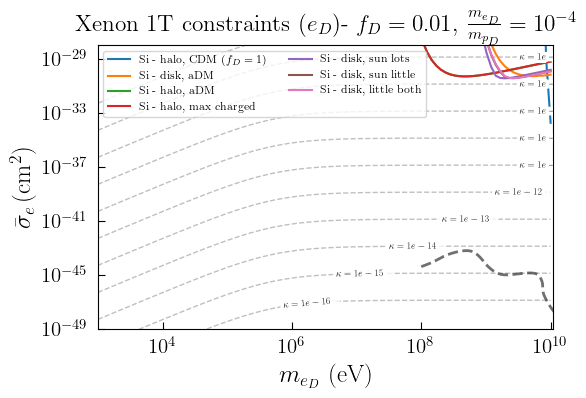

In [22]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)


fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
#labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#           ha='center',va='center',align=True,bbox=props)

compare to mtwh paper and nuclear recoil plots

# Atomic Halo Case

In [28]:

kcut=1.2e4 # restrict phase space for massive mediator


targetlabels=["Halo, Atomic"]


masslist_pD = masslist

sqrtmrat = 1e2


In [29]:

mX=1.0e8 # specify the dark matter mass (to be updated later)

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

# vs_list = [{"v0kms":220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01,"with_atomic_ff":True}] # all must be positive
vs_list = [{"v0kms":220,"vesckms": 540,"vekms": 233,"vdist":"halo","fD":0.01,"with_atomic_ff":True}] # all must be positive



target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"],with_atomic_ff=v["with_atomic_ff"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

# flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

# etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [30]:
# convert cm^2 ref electron cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

In [31]:
# same as above for nuclear
# also from 1509.01598

def mu_chiN_GeV(mchi_eV, mN_GeV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * mN_GeV) / (mchi_GeV + mN_GeV)

def kappa_to_sigmaN_ref(kappa, mchi_eV, Z, mN_GeV, qref_GeV=None):
    """
    Reference DM-nucleus cross section for a massless kinetically mixed mediator.

    sigma_N(qref) = 16 pi alpha^2 kappa^2 Z^2 mu_chiN^2 / qref^4

    By default qref = alpha * m_e, matching the usual electron-reference convention.
    """
    if qref_GeV is None:
        qref_GeV = alpha * m_e_GeV

    muN = mu_chiN_GeV(mchi_eV, mN_GeV)

    sigmaN_GeVminus2 = (
        16 * np.pi * alpha**2
        * np.asarray(kappa, dtype=float)**2
        * Z**2
        * muN**2
        / qref_GeV**4
    )

    return sigmaN_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [32]:
def get_limit_AFF(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0,exposure=1,with_atomic_ff=False, alpha_D=1/137, mrat=1e4):
    
    target.update_params(mX=mX,mediator=mediator)

    # with_atomic_ff=False, alpha_D=None, m_eD_eV=None, m_pD_eV=None
    
    if target.with_atomic_ff:
        R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist,with_atomic_ff=target.with_atomic_ff,alpha_D=alpha_D, m_eD_eV=mX / mrat, m_pD_eV=mX)
    else:
        R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)

    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/(R*exposure) # exposure in kg-year (default 1)

In [33]:
task = ("write","read")[0]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_atomic_17_6_26"
fname = "lim_massless_SENSEI_exp_atomic_18_6_26"

if task == "write":

    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit_AFF(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI,with_atomic_ff=target.with_atomic_ff,
                                alpha_D=alpha,
                                mrat=sqrtmrat**2) 
                                for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit_AFF(target,mX,method="grid",mediator="massless",exposure=expSENSEI,with_atomic_ff=target.with_atomic_ff,
                                alpha_D=alpha,
                                mrat=sqrtmrat**2) 
                                for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)


lim_kappa_atomic_e = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

Si


### nuclear recoil

In [34]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
    with_atomic_ff=False,
    alpha_D=1/137, 
    mrat=1e4,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
        with_atomic_ff=with_atomic_ff,
        alpha_D=alpha_D,
        m_eD_eV=mX / mrat,
        m_pD_eV=mX,
    )

    # if R == 0.0:
    #     return 1.0
    if (not np.isfinite(R)) or R <= 0.0:
        return np.inf
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [35]:
lim_massless_nuc=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless_nuc.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
            ER_min_eV = 4.9e3,
            ER_max_eV = 40.9e3, # 1805.12562,
            with_atomic_ff=target.with_atomic_ff,
            alpha_D=alpha,
            mrat=sqrtmrat**2,
        )
        for mX in masslist
    ])

lim_massless_nuc_DD = np.array(lim_massless_nuc)

lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless_nuc[i], masslist)
    for i in range(len(lim_massless_nuc))
]

# use isotope 131 as reference
lim_sigmaN = [
    kappa_to_sigmaN_ref(lim_massless_nuc[i], masslist, 54.0, 131.0)
    for i in range(len(lim_massless_nuc))
]

lim_kappa_atomic_N = lim_massless_nuc_DD

Si


# Plot v dists - Dark Electron (1e-2 mrat) - SENSEI and Xenon Limits (7/5/26)

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e1

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

# need to divide fD by mass ratio to account for lower number density (dictated by dark proton mass rather than dark electron mass for fixed \rho_{DM})
fDcase = 0.01 / sqrtmrat**2 

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":fDcase},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":fDcase}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [24]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [1]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_sqrtmrat_1e1_7_5_26"
fname = "lim_massless_SENSEI_exp_sqrtmrat_1e1_11_5_26"

if task == "write":
    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)

NameError: name 'pkl' is not defined

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 5 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=24494897427.831787). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 6 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=160947691199.96503). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=np.float64(999.9999999

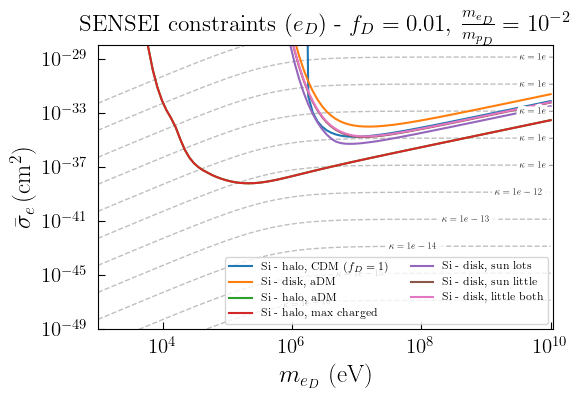

In [26]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-2}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)




# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

### Now Nuclear

In [27]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [28]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist
    ])

lim_massless_DD = np.array(lim_massless)

# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

Si
Si
Si
Si
Si
Si
Si


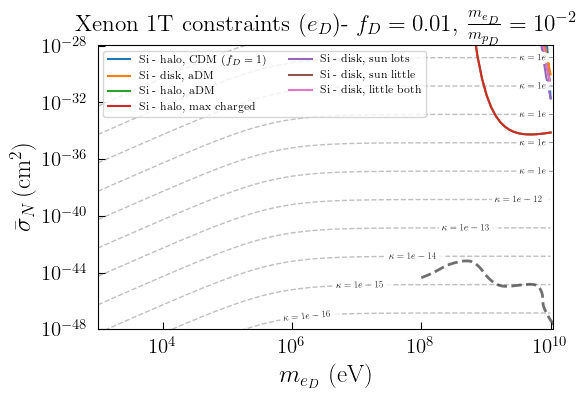

In [29]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-2}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)


fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
#labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#           ha='center',va='center',align=True,bbox=props)

# combined plots for paper

### first attempt scrap

In [ ]:
lim_kappa_pD_e
lim_kappa_pD_N
lim_kappa_eD_e
lim_kappa_eD_N

In [ ]:
targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]


In [87]:
def finite_positive_xy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[mask], y[mask]


def maybe_apply_thermal_cut(x, y, case_index, therm_drops, therm_ind):
    if case_index in therm_drops:
        return x[therm_ind:], y[therm_ind:]
    return x, y


def interp_loglog_y(x, y, x0):
    """
    Interpolate y(x0) in log-log space.
    """
    lx = np.log10(x)
    ly = np.log10(y)
    lx0 = np.log10(x0)

    if lx0 < lx.min() or lx0 > lx.max():
        return None

    ly0 = np.interp(lx0, lx, ly)
    return 10**ly0


def local_loglog_slope(x, y, x0, window=3):
    """
    Estimate d log10(y) / d log10(x) near x0.
    """
    lx = np.log10(x)
    ly = np.log10(y)
    lx0 = np.log10(x0)

    j = np.searchsorted(lx, lx0)
    j = np.clip(j, window, len(x) - window - 1)

    xfit = lx[j-window:j+window+1]
    yfit = ly[j-window:j+window+1]

    slope, intercept = np.polyfit(xfit, yfit, 1)
    return slope


def text_angle_for_loglog_slope(ax, x0, y0, slope):
    """
    Convert a log-log data slope to a screen-space text angle.
    This is important because matplotlib text rotation is in display coordinates.
    """
    x1 = x0
    y1 = y0

    x2 = x0 * 1.5
    y2 = y0 * 1.5**slope

    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))

    dx, dy = p2 - p1
    return np.degrees(np.arctan2(dy, dx))

In [90]:

therm_val = 1e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)

cmap = plt.get_cmap("tab10")
colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
case_labels = {i: targetlabels[i] for i in kept_indices}

species_styles = {
    r"$p_D$": "-",
    r"$e_D$": "--",
}

experiment_alphas = {
    "e": 1.0,
    "N": 0.45,
}

# Replace with your real arrays.
datasets = [
    {
        "species": r"$p_D$",
        "experiment": "e",
        "ydata": lim_kappa_pD_e,
        "mass": masslist,
    },
    {
        "species": r"$p_D$",
        "experiment": "N",
        "ydata": lim_kappa_pD_N,
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "e",
        "ydata": lim_kappa_eD_e,
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "N",
        "ydata": lim_kappa_eD_N,
        "mass": masslist,
    },
]

In [ ]:
# def finite_positive_xy(x, y):
#     """
#     Keep only points valid on a log-log plot.
#     """
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)

#     mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
#     return x[mask], y[mask]


# def maybe_apply_thermal_cut(x, y, case_index, therm_drops, therm_ind):
#     """
#     Apply the thermal cutoff only to cases listed in therm_drops.
#     """
#     if case_index in therm_drops:
#         return x[therm_ind:], y[therm_ind:]
#     return x, y


# def choose_label_point(x, y, frac=0.78):
#     """
#     Pick a point along the curve for the direct label.
#     frac=0.78 places labels near the right side but not exactly at the endpoint.
#     """
#     if len(x) == 0:
#         return None, None

#     j = int(frac * (len(x) - 1))
#     return x[j], y[j]

In [91]:
# ------------------------------------------------------------------
# Label placement choices
# ------------------------------------------------------------------
# The keys are (case_index, species, experiment).
# These are deliberately spread in x so the labels do not pile up.
#
# Start with these, then tune by eye for the final paper plot.

label_x_positions = {}

base_x_by_case = {
    kept_indices[0]: 2.0e12,
    kept_indices[1]: 4.0e12,
    kept_indices[2]: 8.0e12,
    kept_indices[3]: 1.6e13,
}

species_factor = {
    r"$p_D$": 1.0,
    r"$e_D$": 1.9,
}

experiment_factor = {
    "e": 1.0,
    "N": 3.0,
}

for i in kept_indices:
    for species in species_styles:
        for experiment in experiment_alphas:
            label_x_positions[(i, species, experiment)] = (
                base_x_by_case[i]
                * species_factor[species]
                * experiment_factor[experiment]
            )

Text(0.5, 1.0, '$\\kappa$ constraints, $f_D = 0.01$')

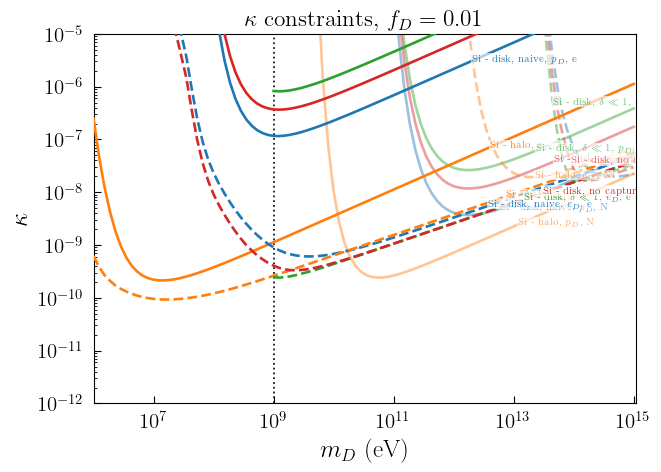

In [92]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

for data in datasets:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    ls = species_styles[species]
    alpha = experiment_alphas[experiment]

    for i in kept_indices:
        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 8:
            continue

        ax.plot(
            x,
            y,
            color=colors[i],
            ls=ls,
            lw=1.9,
            alpha=alpha,
            zorder=3 if alpha > 0.7 else 2,
        )

        # --------------------------------------------------------------
        # Curve-following label
        # --------------------------------------------------------------
        xlab = label_x_positions.get((i, species, experiment), None)

        if xlab is None:
            continue

        ylab = interp_loglog_y(x, y, xlab)

        if ylab is None:
            continue

        # Only label if it lies inside the visible y-range.
        ymin, ymax = 1e-12, 1.0e-5
        if not (ymin < ylab < ymax):
            continue

        slope = local_loglog_slope(x, y, xlab, window=4)
        angle = text_angle_for_loglog_slope(ax, xlab, ylab, slope)

        # Optional small vertical offset in log space.
        # This keeps text from sitting directly on top of the curve.
        yoffset_factor = 1.10

        label = rf"{case_labels[i]}, {species}, {experiment}"

        ax.text(
            xlab,
            ylab * yoffset_factor,
            label,
            fontsize=7.0,
            color=colors[i],
            alpha=min(1.0, alpha + 0.25),
            rotation=angle,
            rotation_mode="anchor",
            ha="left",
            va="center",
            clip_on=True,
            zorder=10,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.65,
                pad=0.8,
            ),
        )

therm_line = ax.axvline(
    therm_val,
    color="black",
    lw=1.3,
    ls=":",
    alpha=0.9,
    zorder=1,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim([1e6, 1.1e15])
ax.set_ylim([1e-12, 1.0e-5])

ax.set_xlabel(r"$m_D$ (eV)", fontsize=18)
ax.set_ylabel(r"$\kappa$", fontsize=18)
ax.tick_params(direction="in", which="both")

ax.set_title(r"$\kappa$ constraints, $f_D = 0.01$")

Text(0.5, 1.0, '$\\kappa$ constraints, $f_D = 0.01$')

NameError: name 'experiment_alphas' is not defined

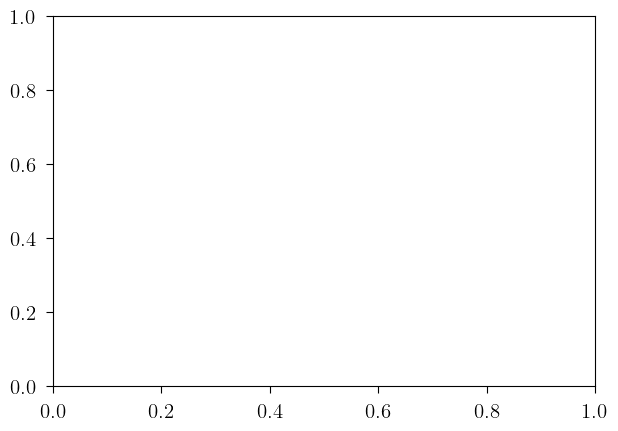

In [95]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

texts = []

for data in datasets:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    ls = species_styles[species]
    alpha = experiment_alphas[experiment]

    for i in kept_indices:
        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        ax.plot(
            x,
            y,
            color=colors[i],
            ls=ls,
            lw=1.8,
            alpha=alpha,
            zorder=3 if alpha > 0.5 else 2,
        )

        # ------------------------------------------------------------------
        # Direct label
        # ------------------------------------------------------------------
        xlab, ylab = choose_label_point(x, y, frac=0.78)

        if xlab is not None:
            # Include all identifying information in the direct label.
            # You can shorten this if the plot gets too busy.
            label = rf"{case_labels[i]}, {species}, {experiment}"

            txt = ax.text(
                xlab,
                ylab,
                label,
                fontsize=7.5,
                color=colors[i],
                alpha=min(1.0, alpha + 0.25),
                ha="left",
                va="center",
                clip_on=True,
            )
            texts.append(txt)


# ------------------------------------------------------------------
# Vertical reference line
# ------------------------------------------------------------------

therm_line = ax.axvline(
    therm_val,
    color="black",
    lw=1.3,
    ls=":",
    alpha=0.9,
    zorder=1,
)

# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim([1e6, 1.1e15])
ax.set_ylim([1e-12, 1.0e-5])

ax.set_xlabel(r"$m_D$ (eV)", fontsize=18)
ax.set_ylabel(r"$\kappa$", fontsize=18)
ax.tick_params(direction="in", which="both")

ax.set_title(r"$\kappa$ constraints, $f_D = 0.01$")


# ------------------------------------------------------------------
# Automatically adjust labels
# ------------------------------------------------------------------

# if HAS_ADJUSTTEXT:
#     adjust_text(
#         texts,
#         ax=ax,
#         only_move={"points": "y", "texts": "y"},
#         expand_text=(1.05, 1.25),
#         expand_points=(1.05, 1.25),
#         force_text=(0.15, 0.5),
#         force_points=(0.1, 0.4),
#         lim=200,
#         arrowprops=dict(
#             arrowstyle="-",
#             lw=0.4,
#             alpha=0.45,
#             color="gray",
#         ),
#     )
# else:
#     print("For better automatic label placement, run: pip install adjustText")

if HAS_ADJUSTTEXT:
    adjust_text(
        texts,
        ax=ax,

        # Keep labels from flying sideways across the plot
        only_move={
            "text": "y",
            "static": "y",
            "explode": "y",
            "pull": "y",
        },

        # Much gentler adjustment
        force_text=(0.02, 0.15),
        force_static=(0.02, 0.15),
        force_pull=(0.005, 0.02),

        # Do not allow huge excursions
        max_move=(0, 8),

        # No arrows. This avoids the FancyArrowPatch warning.
        arrowprops=None,

        # Fewer iterations; prevents pathological rearrangements
        iter_lim=100,
    )

# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

case_handles = [
    Line2D(
        [0], [0],
        color=colors[i],
        lw=2.2,
        label=case_labels[i],
    )
    for i in kept_indices
]

species_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.0,
        ls=ls,
        label=species,
    )
    for species, ls in species_styles.items()
]

experiment_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.0,
        alpha=alpha,
        label=experiment,
    )
    for experiment, alpha in experiment_alphas.items()
]

reference_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=1.3,
        ls=":",
        label=r"$K_{A,S}=10$",
    )
]

leg1 = ax.legend(
    handles=case_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    frameon=False,
)

ax.add_artist(leg1)

leg2 = ax.legend(
    handles=species_handles + experiment_handles + reference_handles,
    title="Encoding",
    fontsize=8,
    title_fontsize=9,
    loc="upper right",
    frameon=False,
)

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)
plt.show()

### second attempt

In [73]:


# targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, naive","Si - halo","Si - halo, max charged",r"Si - disk, $\delta \ll 1$","Si - disk, no capture","Si - disk, little both"]

targetlabels=[r"Si - halo, CDM ($f_D=1$)","disk, naive","halo","halo, max charged",r"Disk, Case B","Disk, Case A and C","Si - disk, little both"]


# kept_indices = (1,2,4,5)
kept_indices = (1,4,5)
therm_drops = (3,4)

# Scenario controls line style
scenario_styles = {
    kept_indices[0]: ":",
    kept_indices[1]: "-",
    kept_indices[2]: "--",
    # kept_indices[3]: (0, (1, 1)),
}

sqrtmrat=1e2


In [74]:
from matplotlib.lines import Line2D
import json
from matplotlib.ticker import FuncFormatter, LogFormatterMathtext

# Optional but strongly recommended:
# pip install adjustText
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False


# ------------------------------------------------------------------
# User inputs / style maps
# ------------------------------------------------------------------



# therm_val = 10**8.92479
therm_val = 0.95e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)

# cmap = plt.get_cmap("tab10")
# colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
# colors[1], colors[2] = colors[2], colors[1]

# # Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices}

# # Species controls line style
# species_styles = {
#     r"$p_D$": "--",
#     r"$e_D$": "-",
# }

# # Experiment controls line width
# experiment_lws = {
#     "SENSEI": 2.2,
#     "Xenon1T": 1.1,
# }



# Species controls line width
species_lws = {
    r"$p_D$": 1.2,
    r"$e_D$": 3.0,
}

# Experiment controls color
cmap = plt.get_cmap("tab10")
experiment_colors = {
    "SENSEI": "b",# cmap(0),
    "Xenon1T": "r", #cmap(1),
    "OSCURA": "c", # for OSCURA
}


expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
expOSCURA = 30 # [kg-yr] projected exposure from 2202.10518
eR_rescale = expSENSEI / expOSCURA

# Each entry should be indexed by case i:
#
#   ydata[i] = constraint curve for case i
#
datasets = [
    {
        "species": r"$p_D$",
        "experiment": "SENSEI",
        "ydata": lim_kappa_pD_e,
        "mass": masslist,
    },
    {
        "species": r"$p_D$",
        "experiment": "Xenon1T",
        "ydata": lim_kappa_pD_N,
        "mass": masslist,
    },
    {
        "species": r"$p_D$",
        "experiment": "OSCURA",
        "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_pD_e),masslist) * eR_rescale,masslist),
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "SENSEI",
        "ydata": lim_kappa_eD_e,
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "Xenon1T",
        "ydata": lim_kappa_eD_N,
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "OSCURA",
        "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_eD_e),masslist) * eR_rescale,masslist),
        "mass": masslist,
    },
]





In [52]:
def finite_positive_xy(x, y):
    """
    Keep only points valid on a log-log plot.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[mask], y[mask]


def maybe_apply_thermal_cut(x, y, case_index, therm_drops, therm_ind):
    """
    Apply the thermal cutoff only to cases listed in therm_drops.
    """
    if case_index in therm_drops:
        return x[therm_ind:], y[therm_ind:]
    return x, y


def choose_label_point(x, y, frac=0.78):
    """
    Pick a point along the curve for the direct label.
    frac=0.78 places labels near the right side but not exactly at the endpoint.
    """
    if len(x) == 0:
        return None, None

    j = int(frac * (len(x) - 1))
    return x[j], y[j]

def load_log_contour_from_json(filename, index):
    """
    Load one contour branch from K_SM_E_contours.json.

    File format:
        [
            [[log10_x1, log10_y1], [log10_x2, log10_y2], ...],
            [[log10_x1, log10_y1], [log10_x2, log10_y2], ...]
        ]

    Returns:
        x = 10**log10_x
        y = 10**log10_y
    """
    with open(filename, "r") as f:
        data = json.load(f)

    arr = np.asarray(data[index], dtype=float)

    logx = arr[:, 0]
    logy = arr[:, 1]

    x = 10.0**logx
    y = 10.0**logy

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

    return x[mask], y[mask]


def shade_above_contour(ax, x, y, y_upper, color="gray", alpha=0.15, zorder=0):
    """
    Shade the region above a contour y(x).

    Assumes x and y are already in physical units, not log units.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Sort by x so fill_between behaves correctly
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    ax.fill_between(
        x,
        y,
        y_upper,
        color=color,
        alpha=alpha,
        zorder=zorder,
    )

### Extract Cosmo Constraints

In [39]:
import fitz  # pymupdf
# import numpy as np
# import matplotlib.pyplot as plt
from matplotlib.path import Path
import pandas as pd

pdf_file = "MCPplot.pdf"
doc = fitz.open(pdf_file)
page = doc[0]
drawings = page.get_drawings()

# ------------------------------------------------------------------
# Plot box calibration from the PDF coordinates
# ------------------------------------------------------------------
# These are approximate from the rendered PDF.
# Tune slightly if the overlay is shifted.
x_pdf_left   = 45.296997
x_pdf_right  = 395.5
y_pdf_top    = 5.625
y_pdf_bottom = 355.828

x_data_min, x_data_max = 2, 14
y_data_min, y_data_max = -14, 0

def pdf_to_data(xpdf, ypdf):
    x = x_data_min + (xpdf - x_pdf_left) / (x_pdf_right - x_pdf_left) * (x_data_max - x_data_min)
    y = y_data_min + (y_pdf_bottom - ypdf) / (y_pdf_bottom - y_pdf_top) * (y_data_max - y_data_min)
    return x, y

In [40]:
def sample_cubic(p0, p1, p2, p3, n=40):
    t = np.linspace(0, 1, n)
    pts = (
        (1 - t)[:, None]**3 * np.array([p0.x, p0.y])
        + 3 * (1 - t)[:, None]**2 * t[:, None] * np.array([p1.x, p1.y])
        + 3 * (1 - t)[:, None] * t[:, None]**2 * np.array([p2.x, p2.y])
        + t[:, None]**3 * np.array([p3.x, p3.y])
    )
    return pts

def drawing_to_polygon_data(d, n_bezier=40):
    pts_pdf = []

    for item in d["items"]:
        kind = item[0]

        if kind == "l":
            p0, p1 = item[1], item[2]
            pts_pdf.append([p0.x, p0.y])
            pts_pdf.append([p1.x, p1.y])

        elif kind == "c":
            p0, p1, p2, p3 = item[1], item[2], item[3], item[4]
            pts_pdf.extend(sample_cubic(p0, p1, p2, p3, n=n_bezier))

        elif kind == "re":
            # Rectangle
            r = item[1]
            pts_pdf.extend([
                [r.x0, r.y0],
                [r.x1, r.y0],
                [r.x1, r.y1],
                [r.x0, r.y1],
                [r.x0, r.y0],
            ])

    if len(pts_pdf) < 3:
        return None

    pts_pdf = np.array(pts_pdf, dtype=float)
    x, y = pdf_to_data(pts_pdf[:, 0], pts_pdf[:, 1])
    pts_data = np.column_stack([x, y])

    return pts_data

In [41]:
polygons = []

for i, d in enumerate(drawings):
    fill = d.get("fill")
    if fill is None:
        continue

    fill = np.array(fill)

    # Skip nearly white or nearly black/gray objects if desired.
    # Colored regions usually have non-equal RGB components.
    is_gray = np.max(fill) - np.min(fill) < 0.03
    is_white = np.all(fill > 0.95)

    if is_gray or is_white:
        continue

    pts = drawing_to_polygon_data(d)
    if pts is None:
        continue

    # Keep only objects with some overlap with the data range
    x, y = pts[:, 0], pts[:, 1]
    overlaps_plot = (
        x.max() >= x_data_min and x.min() <= x_data_max and
        y.max() >= y_data_min and y.min() <= y_data_max
    )
    if not overlaps_plot:
        continue

    # Rough area filter to avoid tiny labels/markers
    area_box = (x.max() - x.min()) * (y.max() - y.min())
    if area_box < 0.02:
        continue

    polygons.append(pts)

print(f"Kept {len(polygons)} filled colored polygons")

Kept 11 filled colored polygons


In [42]:
# ------------------------------------------------------------------
# Rasterize union in log-coordinate data space
# ------------------------------------------------------------------

Nx, Ny = 1800, 1800   # increase for more precision

xgrid = np.linspace(x_data_min, x_data_max, Nx)
ygrid = np.linspace(y_data_min, y_data_max, Ny)

X, Y = np.meshgrid(xgrid, ygrid)
points = np.column_stack([X.ravel(), Y.ravel()])

union_mask = np.zeros(points.shape[0], dtype=bool)

for pts in polygons:
    path = Path(pts)
    union_mask |= path.contains_points(points)

union_mask = union_mask.reshape(Y.shape)

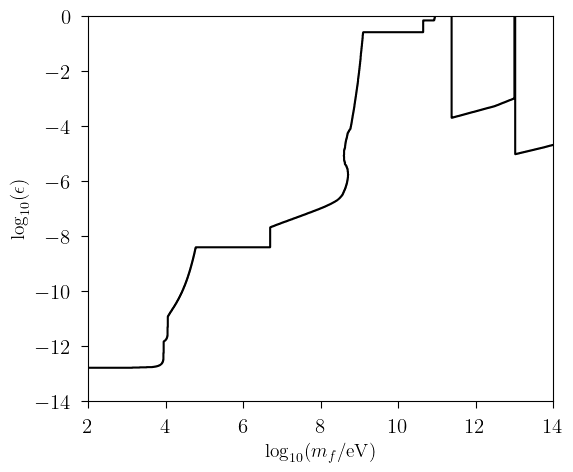

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))

cs = ax.contour(
    X,
    Y,
    union_mask.astype(float),
    levels=[0.5],
    colors="k",
    linewidths=1.5,
)

ax.set_xlim(2, 14)
ax.set_ylim(-14, 0)
ax.set_xlabel(r"$\log_{10}(m_f/\mathrm{eV})$")
ax.set_ylabel(r"$\log_{10}(\epsilon)$")

plt.show()

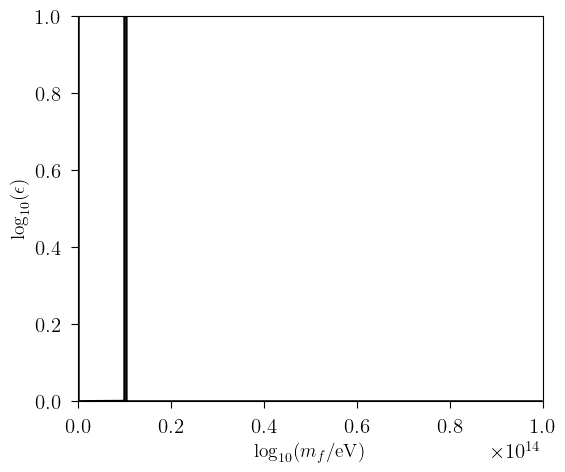

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

cs = ax.contour(
    10**X,
    10**Y,
    union_mask.astype(float),
    levels=[0.5],
    colors="k",
    linewidths=1.5,
)

ax.set_xlim(1e2, 1e14)
ax.set_ylim(1e-14, 1e0)
ax.set_xlabel(r"$\log_{10}(m_f/\mathrm{eV})$")
ax.set_ylabel(r"$\log_{10}(\epsilon)$")

plt.show()

### money plot

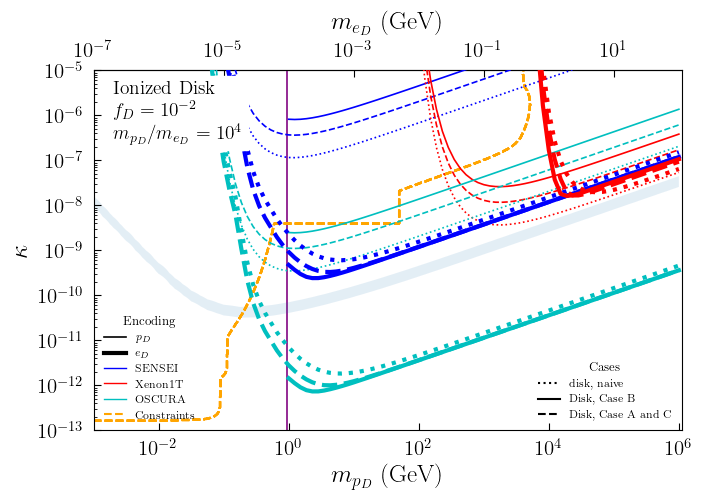

In [89]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

texts = []


# therm_val = 10**8.92479
therm_val = 0.95e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)


for data in datasets:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    # ls = species_styles[species]
    # alpha = experiment_alphas[experiment]
    # lw = experiment_lws[experiment]

    for i in kept_indices:
        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        # ax.plot(
        #     x,
        #     y,
        #     color=colors[i],
        #     ls=ls,
        #     lw=lw,
        #     # lw=1.8,
        #     # alpha=alpha,
        #     zorder=3 if alpha > 0.5 else 2,
        # )

        ax.plot(
        x,
        y,
        color=experiment_colors[experiment],
        ls=scenario_styles[i],
        lw=species_lws[species],
        zorder=3,
)



# ------------------------------------------------------------------
# Vertical reference line
# ------------------------------------------------------------------

therm_line = ax.axvline(
    therm_val,
    color="purple",
    lw=1.3,
    ls="-",
    alpha=0.9,
    zorder=1,
)

# therm_line = ax.axvline(
#     10**8.58272,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim([1e6, 1.1e15])
ax.set_ylim([1e-13, 1.0e-5])


ax.text(2e6,3e-7,"Ionized Disk \n $f_D=10^{-2}$ \n $m_{p_D}/m_{e_D}=10^4$",fontsize=14,backgroundcolor="white",horizontalalignment="left")


eVtoGeV = 10**(-9)
ax.xaxis.set_major_formatter(
    lambda value, position: LogFormatterMathtext()(eVtoGeV * value)
)


ax.set_xlabel(r"$m_{p_D}$ (GeV)", fontsize=18)
ax.set_ylabel(r"$\kappa$", fontsize=18)
ax.tick_params(direction="in", which="both")

# ax.set_title(r"$\kappa$ constraints, $f_D = 0.01$")

y_upper = ax.get_ylim()[1]



# ------------------------------------------------------------------
# Extra contours from JSON
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)


# shade_above_contour(
#     ax,
#     x_c1,
#     y_c1,
#     y_upper,
#     color="gray",
#     alpha=0.12,
#     zorder=0,
# )

# shade_above_contour(
#     ax,
#     x_c2,
#     y_c2,
#     y_upper,
#     color="gray",
#     alpha=0.12,
#     zorder=0,
# )

# ax.plot(
#     x_c1,
#     y_c1,
#     color="gray",
#     ls="-",
#     lw=1.8,
#     alpha=0.95,
#     zorder=6,
# )

# ax.plot(
#     x_c2,
#     y_c2,
#     color="dimgray",
#     # ls=(0, (3, 1, 1, 1)),
#     ls="-",
#     lw=1.8,
#     alpha=0.95,
#     zorder=6,
# )

# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2))
xmax = min(np.max(x_c1), np.max(x_c2))

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1, y_c1)
y2_common = np.interp(x_common, x_c2, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

ax.fill_between(
    x_common,
    y1_common,
    y2_common,
    alpha=0.12,
    zorder=1,
)

# ------------------------------------------------------------------
# Secondary top x-axis
# ------------------------------------------------------------------

mrat = eVtoGeV * 1.0 / sqrtmrat**2 

def bottom_to_top(x):
    return mrat * x

def top_to_bottom(x_top):
    return x_top / mrat

secax = ax.secondary_xaxis(
    "top",
    functions=(bottom_to_top, top_to_bottom),
)

secax.set_xscale("log")
secax.set_xlabel(r"$m_{e_D}$ (GeV)", fontsize=18,labelpad=10)
secax.tick_params(direction="in", which="both")

# ------------------------------------------------------------------
# Automatically adjust labels
# ------------------------------------------------------------------

# if HAS_ADJUSTTEXT:
#     adjust_text(
#         texts,
#         ax=ax,
#         only_move={"points": "y", "texts": "y"},
#         expand_text=(1.05, 1.25),
#         expand_points=(1.05, 1.25),
#         force_text=(0.15, 0.5),
#         force_points=(0.1, 0.4),
#         lim=200,
#         arrowprops=dict(
#             arrowstyle="-",
#             lw=0.4,
#             alpha=0.45,
#             color="gray",
#         ),
#     )
# else:
#     print("For better automatic label placement, run: pip install adjustText")

if HAS_ADJUSTTEXT:
    adjust_text(
        texts,
        ax=ax,

        # Keep labels from flying sideways across the plot
        only_move={
            "text": "y",
            "static": "y",
            "explode": "y",
            "pull": "y",
        },

        # Much gentler adjustment
        force_text=(0.02, 0.15),
        force_static=(0.02, 0.15),
        force_pull=(0.005, 0.02),

        # Do not allow huge excursions
        max_move=(0, 8),

        # No arrows. This avoids the FancyArrowPatch warning.
        arrowprops=None,

        # Fewer iterations; prevents pathological rearrangements
        iter_lim=100,
    )

# ------------------------------------------------------------------
# cosmo contours from 1311.2600
# ------------------------------------------------------------------

cs = ax.contour(
    10**X * sqrtmrat**2,
    10**Y,
    union_mask.astype(float),
    # levels=[0.5],
    colors="orange",
    linewidths=1.5,
    linestyles="--",
)


# # ------------------------------------------------------------------
# # Encoding legends
# # ------------------------------------------------------------------
# # Instead of one huge curve legend, make compact legends explaining the visual code.

# case_handles = [
#     Line2D(
#         [0], [0],
#         color=colors[i],
#         lw=2.2,
#         label=case_labels[i],
#     )
#     for i in kept_indices
# ]

# species_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         lw=2.0,
#         ls=ls,
#         label=species,
#     )
#     for species, ls in species_styles.items()
# ]

# experiment_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         # lw=2.0,
#         # alpha=alpha,
#         lw=lw,
#         label=experiment,
#     )
#     # for experiment, alpha in experiment_alphas.items()
#     for experiment, lw in experiment_lws.items()
# ]

# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     )
# ]



# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     ),
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.1,
#         ls="-",
#         alpha=0.6,
#         label=r"$K_{A,S}=1$",
#     )
# ]

# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

# color=experiment_colors[experiment],
#         ls=scenario_styles[i],
#         lw=species_lws[species],

case_handles = [
    Line2D(
        [0], [0],
        # color=colors[i],
        color="black",
        ls=scenario_styles[i],
        label=case_labels[i],
    )
    for i in kept_indices
]

species_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=lw,
        ls="-",
        label=species,
    )
    for species, lw in species_lws.items()
]

experiment_handles = [
    Line2D(
        [0], [0],
        # color="black",
        color=experiment_colors[experiment],
        # lw=2.0,
        # alpha=alpha,
        lw=1.0,
        label=experiment,
    )
    # for experiment, alpha in experiment_alphas.items()
    for experiment, color in experiment_colors.items()
]


cosmo_handles = [
    Line2D(
        [0], [0],
        color="orange",
        lw=1.5,
        ls="--",
        label="Constraints"
    )
    ]

reference_handles = []

leg1 = ax.legend(
    handles=case_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    frameon=False,
)

ax.add_artist(leg1)

leg2 = ax.legend(
    handles=species_handles + experiment_handles + reference_handles+cosmo_handles,
    title="Encoding",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    frameon=False,
)

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)
plt.show()

### electrons only 

In [109]:

# targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]
targetlabels=[r"Si - halo, CDM ($f_D=1$)","Disk, Naive","Halo, Ionized","Si - halo, max charged","Disk, Case B","Disk, Case A and C","Si - disk, little both"]

masslist_eD = masslist / sqrtmrat**2

kept_indices = (1,2,4,5)
therm_drops = (3,4)

halo_index = (2)

# Scenario controls line style
scenario_styles = {
    kept_indices[0]: ":",
    kept_indices[1]: "-.",
    kept_indices[2]: "-",
    kept_indices[3]: "--",
    # kept_indices[3]: (0, (1, 1)),
}

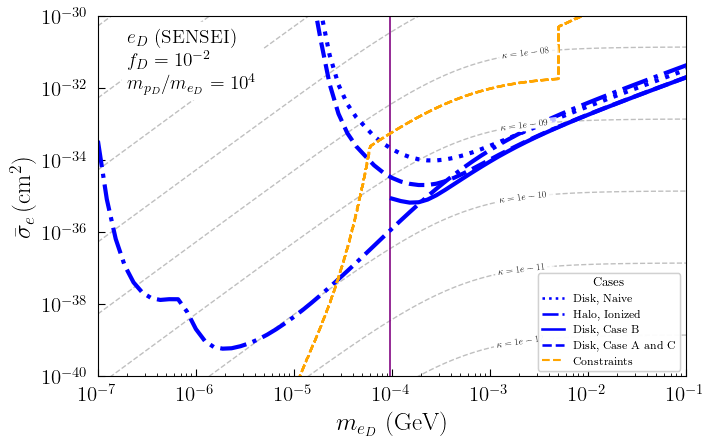

In [110]:
# fig, axs = plt.subplots(figsize=(6,4.2))
fig, axs = plt.subplots(figsize=(7.0, 4.8))

# cmap = plt.get_cmap('tab10')
# colors = cmap(np.linspace(0.0,1.0,10))
cmap = plt.get_cmap("tab10")
# colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
# colors[1], colors[2] = colors[2], colors[1]

# Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices}


# eVtoGeV = 10**(-9)

# masslist_eD_GeV = masslist_eD * eVtoGeV


# therm_val = eVtoGeV * 1e9 / sqrtmrat**2
# therm_ind = next(j for j, x in enumerate(masslist_eD_GeV) if x >= therm_val)

# therm_val = 1e9 / sqrtmrat**2
therm_val = 0.95e9 / sqrtmrat**2
therm_ind = next(j for j, x in enumerate(masslist_eD) if x >= therm_val)



# for i in kept_indices:
#     axs.plot(
#         masslist[therm_ind:] if (i in therm_drops) else masslist,
#         lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
#         label=targetlabels[i],
#         color=colors[i]
#     )

# ls = species_styles[r"$e_D$"]
# # alpha = experiment_alphas[experiment]
# lw = experiment_lws["SENSEI"]

spc_lw = species_lws[r"$e_D$"]
exp_color = experiment_colors["SENSEI"]


lim_data = next(
    (item.get("ydata") for item in datasets if item.get("species") == r"$e_D$"),
    None
)

lim_data = kappa_to_sigmae_exact(lim_data, masslist_eD)


# for i in kept_indices:
#     axs.plot(
#         masslist_eD_GeV[therm_ind:] if (i in therm_drops) else masslist_eD_GeV,
#         lim_data[i][therm_ind:] if (i in therm_drops) else lim_data[i],
#         label=targetlabels[i],
#         color=colors[i]
#     )

# ax.plot(
#         x,
#         y,
#         color=experiment_colors[experiment],
#         ls=scenario_styles[i],
#         lw=species_lws[species],
#         zorder=3,
# )

for i in kept_indices:
    axs.plot(
        masslist_eD[therm_ind:] if (i in therm_drops) else masslist_eD,
        lim_data[i][therm_ind:] if (i in therm_drops) else lim_data[i],
        label=targetlabels[i],
        color=exp_color,
        lw=spc_lw,
        ls=scenario_styles[i],
    )
    #  ax.plot(
    #     x,
    #     y,
    #     color=experiment_colors[experiment],
    #     ls=scenario_styles[i],
    #     lw=species_lws[species],
    #     zorder=3,



# # Example: convert x values from eV to GeV
# axs.xaxis.set_major_formatter(
#     FuncFormatter(lambda value, position: f"{value / 1e9:g}")
# )

axs.set_xscale("log")   
axs.set_yscale("log")

# axs.set_xlim([eVtoGeV * 1e2, eVtoGeV * 1.0e8])
axs.set_xlim([1e2, 1.0e8])
axs.set_ylim([1e-40, 1.0e-30])


# # Example: convert x values from eV to GeV
# axs.xaxis.set_major_formatter(
#     FuncFormatter(lambda value, position: f"{value / 1e9:g}")
# )


axs.text(2e2,1e-32,"$e_{D}$ (SENSEI)\n $f_D=10^{-2}$ \n $m_{p_D}/m_{e_D}=10^4$",fontsize=14,backgroundcolor="white",horizontalalignment="left")


eVtoGeV = 10**(-9)
axs.xaxis.set_major_formatter(
    lambda value, position: LogFormatterMathtext()(eVtoGeV * value)
)

# axs.set_xscale("log")   
# axs.set_yscale("log")

axs.set_xlabel("$m_{e_D}$ (GeV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title(r"SENSEI ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# cosmo contours from 1311.2600
# ------------------------------------------------------------------

cs = axs.contour(
    10**X,
    kappa_to_sigmae_exact(10**Y, 10**X),
    union_mask.astype(float),
    # levels=[0.5],
    colors="orange",
    linewidths=1.5,
    linestyles="--",
)



# ------------------------------------------------------------------
# Vertical reference line
# ------------------------------------------------------------------

therm_line = axs.axvline(
    therm_val,
    color="purple",
    lw=1.3,
    ls="-",
    alpha=0.9,
    zorder=1,
)

# therm_line = axs.axvline(
#     eVtoGeV * 10**8.58272 / sqrtmrat**2,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# therm_line = axs.axvline(
#     10**8.58272 / sqrtmrat**2,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist_eD)

    # line, = axs.plot(
    #     masslist_eD_GeV,
    #     sig_line,
    #     color="black",
    #     alpha=0.25,
    #     lw=1.0,
    #     ls="--",
    #     zorder=0.5,
    #     label=rf"$\kappa={kap:.0e}$"
    # )

    
    line, = axs.plot(
        masslist_eD,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
# xvals_kappa = np.geomspace(2e6 * eVtoGeV, 3e6 * eVtoGeV, len(kappa_lines))
xvals_kappa = np.geomspace(2e6 , 3e6 , len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Shade region to the right of the vertical contours
# ------------------------------------------------------------------

# x_right = axs.get_xlim()[0]

# vline_1 = therm_val
# vline_2 = 10**8.58272 / sqrtmrat**2

# # If the excluded/shaded region is to the right of BOTH contours,
# # start shading at the rightmost contour.
# x_shade_start = max(vline_1, vline_2)

# axs.axvspan(
#     x_shade_start,
#     x_right,
#     color="purple",
#     alpha=0.06,
#     lw=0,
#     zorder=0,
# )

# x_shade_start = min(vline_1, vline_2)

# axs.axvspan(
#     x_shade_start,
#     x_right,
#     color="purple",
#     alpha=0.08,
#     lw=0,
#     zorder=0,
# )


# # ------------------------------------------------------------------
# # cosmo contours from 1311.2600
# # ------------------------------------------------------------------

# cs = axs.contour(
#     10**X ,
#     10**Y,
#     union_mask.astype(float),
#     levels=[0.5],
#     colors="k",
#     linewidths=1.5,
# )

# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

# case_handles = [
#     Line2D(
#         [0], [0],
#         color=colors[i],
#         lw=2.2,
#         label=case_labels[i],
#     )
#     for i in kept_indices
# ]

case_handles = [
    Line2D(
        [0], [0],
        color=exp_color,
        lw=1.8,
        ls=scenario_styles[i],
        label=case_labels[i],
    )
    for i in kept_indices
]


cosmo_handles = [
    Line2D(
        [0], [0],
        color="orange",
        lw=1.5,
        ls="--",
        label="Constraints"
    )
    ]


reference_handles = []

leg1 = axs.legend(
    handles=case_handles+cosmo_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    # frameon=False,
    frameon=True,
    facecolor="white"
)

axs.add_artist(leg1)

fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)
plt.show()

### Money Plot Halo and atomic

In [92]:
targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Halo, Ionized","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both","Halo, Atomic"]
# targetlabels=["Halo, Ionized","Halo, Atomic"]

# masslist_eD = masslist / sqrtmrat**2

kept_indices = [2]
kept_indices_atomic = [-1]
therm_drops = (3,4)

# halo_index = (2)

# Scenario controls line style
scenario_styles = {
    kept_indices[0]: "-",
    kept_indices_atomic[0]: "--"
}

In [93]:
datasets_atomic = [
    # {
    #     "species": r"$p_D$",
    #     "experiment": "SENSEI",
    #     "ydata": lim_kappa_pD_e,
    #     "mass": masslist,
    # },
    # {
    #     "species": r"$p_D$",
    #     "experiment": "Xenon1T",
    #     "ydata": lim_kappa_pD_N,
    #     "mass": masslist,
    # },
    # {
    #     "species": r"$p_D$",
    #     "experiment": "OSCURA",
    #     "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_pD_e),masslist) * eR_rescale,masslist),
    #     "mass": masslist,
    # },
    # {
    #     "species": r"$e_D$",
    #     "experiment": "SENSEI",
    #     "ydata": lim_kappa_eD_e,
    #     "mass": masslist,
    # },
    # {
    #     "species": r"$e_D$",
    #     "experiment": "Xenon1T",
    #     "ydata": lim_kappa_eD_N,
    #     "mass": masslist,
    # },
    # {
    #     "species": r"$e_D$",
    #     "experiment": "OSCURA",
    #     "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_eD_e),masslist) * eR_rescale,masslist),
    #     "mass": masslist,
    # },
    {
        "species": "Atomic",
        "experiment": "SENSEI",
        "ydata": lim_kappa_atomic_e,
        "mass": masslist,
    },
    {
        "species": "Atomic",
        "experiment": "Xenon1T",
        "ydata": lim_kappa_atomic_N,
        "mass": masslist,
    },
    {
        "species": "Atomic",
        "experiment": "OSCURA",
        "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_atomic_e),masslist) * eR_rescale,masslist),
        "mass": masslist,
    },
]

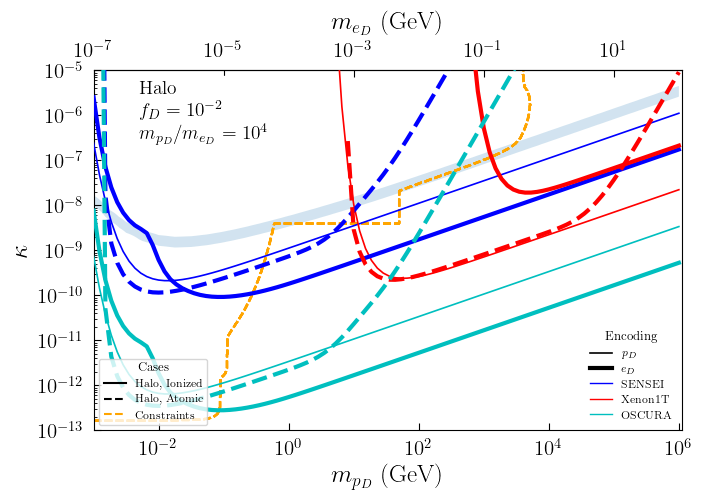

In [97]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

texts = []


# Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices+kept_indices_atomic}


# therm_val = 10**8.92479
# therm_val = 0.95e9
therm_val = 10**(7.54)
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)


for data in datasets:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    # ls = species_styles[species]
    # alpha = experiment_alphas[experiment]
    # lw = experiment_lws[experiment]

    for i in kept_indices:
    # if True:
        # i = halo_index

        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        # ax.plot(
        #     x,
        #     y,
        #     color=colors[i],
        #     ls=ls,
        #     lw=lw,
        #     # lw=1.8,
        #     # alpha=alpha,
        #     zorder=3 if alpha > 0.5 else 2,
        # )

        ax.plot(
        x,
        y,
        color=experiment_colors[experiment],
        ls=scenario_styles[i],
        lw=species_lws[species],
        zorder=3,
)



for data in datasets_atomic:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    # ls = species_styles[species]
    # alpha = experiment_alphas[experiment]
    # lw = experiment_lws[experiment]

    for i in kept_indices_atomic:
    # if True:
        # i = halo_index

        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        # ax.plot(
        #     x,
        #     y,
        #     color=colors[i],
        #     ls=ls,
        #     lw=lw,
        #     # lw=1.8,
        #     # alpha=alpha,
        #     zorder=3 if alpha > 0.5 else 2,
        # )

        ax.plot(
        x,
        y,
        color=experiment_colors[experiment],
        ls=scenario_styles[i],
        lw=species_lws[r"$e_D$"],
        zorder=3,
)


# ------------------------------------------------------------------
# Vertical reference line
# ------------------------------------------------------------------

# therm_line = ax.axvline(
#     therm_val,
#     color="purple",
#     lw=1.3,
#     ls="-",
#     alpha=0.9,
#     zorder=1,
# )

# therm_line = ax.axvline(
#     10**7.20,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim([1e6, 1.1e15])
ax.set_ylim([1e-13, 1.0e-5])


ax.text(5e6,3e-7,"Halo \n $f_D=10^{-2}$ \n $m_{p_D}/m_{e_D}=10^4$",fontsize=14,backgroundcolor="white",horizontalalignment="left")


eVtoGeV = 10**(-9)
ax.xaxis.set_major_formatter(
    lambda value, position: LogFormatterMathtext()(eVtoGeV * value)
)


ax.set_xlabel(r"$m_{p_D}$ (GeV)", fontsize=18)
ax.set_ylabel(r"$\kappa$", fontsize=18)
ax.tick_params(direction="in", which="both")

# ax.set_title(r"$\kappa$ constraints, $f_D = 0.01$")

y_upper = ax.get_ylim()[1]

# ------------------------------------------------------------------
# Extra contours from JSON
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours_Halo.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)

# shade_above_contour(
#     ax,
#     x_c1,
#     y_c1,
#     y_upper,
#     color="gray",
#     alpha=0.12,
#     zorder=0,
# )

# shade_above_contour(
#     ax,
#     x_c2,
#     y_c2,
#     y_upper,
#     color="gray",
#     alpha=0.12,
#     zorder=0,
# )

# ax.plot(
#     x_c1,
#     y_c1,
#     color="gray",
#     ls="-",
#     lw=1.8,
#     alpha=0.95,
#     zorder=6,
# )

# ax.plot(
#     x_c2,
#     y_c2,
#     color="dimgray",
#     # ls=(0, (3, 1, 1, 1)),
#     ls="-",
#     lw=1.8,
#     alpha=0.95,
#     zorder=6,
# )

# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2))
xmax = min(np.max(x_c1), np.max(x_c2))

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1, y_c1)
y2_common = np.interp(x_common, x_c2, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

ax.fill_between(
    x_common,
    y1_common,
    y2_common,
    alpha=0.20,
    zorder=1,
)


# ------------------------------------------------------------------
# Extra contours from JSON (atomic)
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours_Halo_atomic.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)

# shade_above_contour(
#     ax,
#     x_c1,
#     y_c1,
#     y_upper,
#     color="gray",
#     alpha=0.12,
#     zorder=0,
# )

# shade_above_contour(
#     ax,
#     x_c2,
#     y_c2,
#     y_upper,
#     color="gray",
#     alpha=0.12,
#     zorder=0,
# )

# ax.plot(
#     x_c1,
#     y_c1,
#     color="gray",
#     ls="--",
#     lw=1.8,
#     alpha=0.95,
#     zorder=6,
# )

# ax.plot(
#     x_c2,
#     y_c2,
#     color="dimgray",
#     # ls=(0, (3, 1, 1, 1)),
#     ls="--",
#     lw=1.8,
#     alpha=0.95,
#     zorder=6,
# )

# # Fill between contours
# xmin = max(np.min(x_c1), np.min(x_c2))
# xmax = min(np.max(x_c1), np.max(x_c2))

# x_common = np.logspace(
#     np.log10(xmin),
#     np.log10(xmax),
#     1000,
# )

# y1_common = np.interp(x_common, x_c1, y_c1)
# y2_common = np.interp(x_common, x_c2, y_c2)

# # ax.plot(x_c1, y_c1)
# # ax.plot(x2, y2)

# ax.fill_between(
#     x_common,
#     y1_common,
#     y2_common,
#     alpha=0.20,
#     zorder=1,
# )

# ------------------------------------------------------------------
# Secondary top x-axis
# ------------------------------------------------------------------

mrat = eVtoGeV * 1.0 / sqrtmrat**2 

def bottom_to_top(x):
    return mrat * x

def top_to_bottom(x_top):
    return x_top / mrat

secax = ax.secondary_xaxis(
    "top",
    functions=(bottom_to_top, top_to_bottom),
)

secax.set_xscale("log")
secax.set_xlabel(r"$m_{e_D}$ (GeV)", fontsize=18,labelpad=10)
secax.tick_params(direction="in", which="both")

# ------------------------------------------------------------------
# Automatically adjust labels
# ------------------------------------------------------------------

# if HAS_ADJUSTTEXT:
#     adjust_text(
#         texts,
#         ax=ax,
#         only_move={"points": "y", "texts": "y"},
#         expand_text=(1.05, 1.25),
#         expand_points=(1.05, 1.25),
#         force_text=(0.15, 0.5),
#         force_points=(0.1, 0.4),
#         lim=200,
#         arrowprops=dict(
#             arrowstyle="-",
#             lw=0.4,
#             alpha=0.45,
#             color="gray",
#         ),
#     )
# else:
#     print("For better automatic label placement, run: pip install adjustText")

if HAS_ADJUSTTEXT:
    adjust_text(
        texts,
        ax=ax,

        # Keep labels from flying sideways across the plot
        only_move={
            "text": "y",
            "static": "y",
            "explode": "y",
            "pull": "y",
        },

        # Much gentler adjustment
        force_text=(0.02, 0.15),
        force_static=(0.02, 0.15),
        force_pull=(0.005, 0.02),

        # Do not allow huge excursions
        max_move=(0, 8),

        # No arrows. This avoids the FancyArrowPatch warning.
        arrowprops=None,

        # Fewer iterations; prevents pathological rearrangements
        iter_lim=100,
    )

# ------------------------------------------------------------------
# cosmo contours from 1311.2600
# ------------------------------------------------------------------

cs = ax.contour(
    10**X * sqrtmrat**2,
    10**Y,
    union_mask.astype(float),
    # levels=[0.5],
    colors="orange",
    linewidths=1.5,
    linestyles="--",
)


# # ------------------------------------------------------------------
# # Encoding legends
# # ------------------------------------------------------------------
# # Instead of one huge curve legend, make compact legends explaining the visual code.

# case_handles = [
#     Line2D(
#         [0], [0],
#         color=colors[i],
#         lw=2.2,
#         label=case_labels[i],
#     )
#     for i in kept_indices
# ]

# species_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         lw=2.0,
#         ls=ls,
#         label=species,
#     )
#     for species, ls in species_styles.items()
# ]

# experiment_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         # lw=2.0,
#         # alpha=alpha,
#         lw=lw,
#         label=experiment,
#     )
#     # for experiment, alpha in experiment_alphas.items()
#     for experiment, lw in experiment_lws.items()
# ]

# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     )
# ]



# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     ),
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.1,
#         ls="-",
#         alpha=0.6,
#         label=r"$K_{A,S}=1$",
#     )
# ]

# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

# color=experiment_colors[experiment],
#         ls=scenario_styles[i],
#         lw=species_lws[species],

case_handles = [
    Line2D(
        [0], [0],
        # color=colors[i],
        color="black",
        ls=scenario_styles[i],
        label=case_labels[i],
    )
    for i in kept_indices
    # for i in kept_indices_atomic + kept_indices
]

case_handles_atomic = [
    Line2D(
        [0], [0],
        # color=colors[i],
        color="black",
        ls=scenario_styles[i],
        label=case_labels[i],
    )
    # for i in kept_indices
    for i in kept_indices_atomic
]

species_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=lw,
        ls="-",
        label=species,
    )
    for species, lw in species_lws.items()
]

experiment_handles = [
    Line2D(
        [0], [0],
        # color="black",
        color=experiment_colors[experiment],
        # lw=2.0,
        # alpha=alpha,
        lw=1.0,
        label=experiment,
    )
    # for experiment, alpha in experiment_alphas.items()
    for experiment, color in experiment_colors.items()
]


cosmo_handles = [
    Line2D(
        [0], [0],
        color="orange",
        lw=1.5,
        ls="--",
        label="Constraints"
    )
    ]


reference_handles = []

leg1 = ax.legend(
    handles=case_handles + case_handles_atomic + cosmo_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    # frameon=False,
    frameon=True,
    facecolor="white"
)

ax.add_artist(leg1)

leg2 = ax.legend(
    handles=species_handles + experiment_handles + reference_handles,
    title="Encoding",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    frameon=False,
)

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)
plt.show()

### FF diagnostic

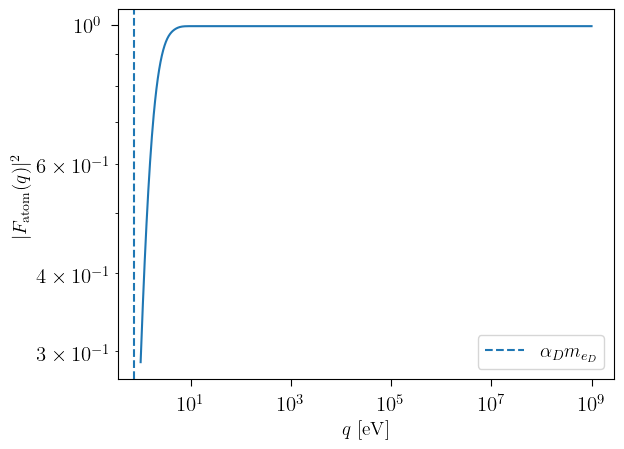

In [70]:


from atomic_dark_hydrogen_ff import dark_hydrogen_screening_squared

q = np.geomspace(1e0, 1e9, 1000)  # eV

m_pD = 1e6
m_eD = 1e6 * 1e-4

F2 = dark_hydrogen_screening_squared(
    q,
    alpha_D=1 / 137.035999084,
    m_eD_eV=m_eD,
    m_pD_eV=m_pD,
)

plt.loglog(q, F2)
plt.axvline(
    (1 / 137.035999084) * m_eD,
    linestyle="--",
    label=r"$\alpha_D m_{e_D}$",
)
plt.xlabel(r"$q\ [{\rm eV}]$")
plt.ylabel(r"$|F_{\rm atom}(q)|^2$")
plt.legend()

In [89]:
from atomic_dark_hydrogen_ff import dark_hydrogen_screening_squared

alpha_D = 1 / 137.035999084
m_eD = 1e9
m_pD = 1e4 * m_eD

omega = 10.0
k = 1e4  # 10 keV

r_off = target_list[0].dRdomegadk_electron(
    omega,
    k,
    sigmae=1e-38,
    with_atomic_ff=False,
)

r_on = target_list[0].dRdomegadk_electron(
    omega,
    k,
    sigmae=1e-38,
    with_atomic_ff=True,
    alpha_D=alpha_D,
    m_eD_eV=m_eD,
    m_pD_eV=m_pD,
)

ff2 = dark_hydrogen_screening_squared(
    k,
    alpha_D=alpha_D,
    m_eD_eV=m_eD,
    m_pD_eV=m_pD,
)

print("rate ratio =", r_on / r_off)
print("AFF squared =", ff2)

rate ratio = nan
AFF squared = 8.720408067830318e-13


C:\Users\keega\AppData\Local\Temp\ipykernel_23508\3147963626.py:34: RuntimeWarning: invalid value encountered in scalar divide
  print("rate ratio =", r_on / r_off)


In [94]:
print("mX =", target_list[0].mX)
print("vmin =", target_list[0].vmin(omega, k))
print("eta  =", target_list[0].etav(target_list[0].vmin(omega, k)))
print("eps2 =", target_list[0].eps2(omega, k, method="grid"))
print("r_off =", r_off)
print("r_on  =", r_on)


mX = 1000000000000000.0
vmin = 0.001000000005
eta  = 0
eps2 = 0.0006242383416707252
r_off = 0.0
r_on  = 0.0
